#### The following is a test to see if the Spectrum Card can work in the following way:
- Monochromatic Tone @ 68 MHz - set time duration for cMOT loading, LACs and possibly imaging
- Frequency sweep with set duration T from 68 to 88 MHz
- Monochromatic tone @ 88 MHz with - hold indefinitely for physics

According to documentation, I can use the Sequence Replay Mode to do the following:
- Divide the memory into three segments, each segment is (not changeable) of length [Installed Memory]/[Number of Segments]
- Fill the three segments with the three different data sequences
- Define for each the next memory segment, the number of loops, and the exit condition

Some technical details regarding the Spectrum Card:
- Memory: 2 GSample = 2 * 1024 * 1024 * 1024 Samples
- Max sampling Rate: 625 MSa/s
- Memory Segmentation: Only powers of 2 are allowed, but empty segments aren't used
- Minimum number of samples per segment: 384 Samples (1 channel active)
- Maximum number of samples per segment: [Memory] / [Number of Segments] Samples
- Stepsize in memory segment: 32 Samples

Ideally, the three sequences are defined with the following constraints:
- A monochromatic signal at frequency f1, sampled for a single period (the number of loops will determine the total duration of it) or integer multiples of it to reach the needed minimum number of samples, with a conditioned interrupt on a trigger, with next sequence the chirp
- A sweep (either chirp or else) going from f1 to f2, repeated only once, with the phase calculated after T_chirp so to have the second wave proceed unterruptedly
-  A final monochromatic signal at frequency f2, sampled even once is enough, looping indefinitely (loop=0)

How will the timings be handled in this sequence? There will be the need of a digital channel that from labscript triggers the sequence in the following way:
- The single tweezer at a certain frequency is kept on indefinitely when ticked in LabScript, and will be activated with the usual TweezerPower variable when needed
- The digital channel going to the Spectrum Card will act as a trigger of the movement (sweep) sequence, so that we can just keep the first tone indefinitely until in the sequence we get the trigger, which does the sweep
- The rest is the same, ater the sweep the tweezer is held in place bythe second monochromatic wave with no other timings issues in the sequence, until the terminal is interrupted as we always did until now

NOTE: *If the card detects a trigger mid-loop (mid-period) of the monochromatic signal, it will WAIT until the end of the period/loop/repetition before going to the next event. This is desired behaviour since it will provide no phase discontinuities with the following chirp (which starts at A(t)=0), but it may cause clock reference mismatches if one were tempted to do something else in the sequence between the trigger event and the actual change in memory segment.
This is the type of scenario where a LabRad/LabScript integration would work better, since the timing can be provided in such a way that we could calculate the phase accumulated before the trigger and have the chirp start with the same phase.*

In [64]:
#%matplotlib qt

In [65]:
import labrad
from labrad import units
import numpy as np
import matplotlib.pyplot as plt
from os import path
import sys

# Uncomment if is to be tested in the lab
#_root = path.abspath(path.join(
#    '//arqusws-01', 'ArQuS Shared', 'LabRAD', 'LabRADCodes', 'servers', 'Spectrum_Card'))
#sys.path.append(_root)
_root = path.abspath(path.join(
    '//arqus-nas', 'ArQuS Shared', 'LabRad', 'servers', 'Spectrum_Card'))
sys.path.append(_root)

import F_wavegen_v3 as wg

In [66]:
#connecting to labrad
cxn = labrad.connect('192.168.1.21', password='ytterbium171')
SC = cxn.m4i_6621_x8
print(f'found {SC._card_type()} with serial number {SC._serial_number()}')
if SC._serial_number()==0:
    raise ValueError('Card not found!')


# Print list of settings
SC
SC._close()
SC._open()

SC._reset()

found M4i.6621-x8 with serial number 18494


In [67]:
MHz = 1e6

In [68]:
# Useful card information
print(f'number of bytes per sample: {SC._bytes_per_sample()}')
max_sa_s = SC._max_sample_rate()
print(f'max sample rate provided by {SC._card_type()} is: {max_sa_s/1e6} MHz')
# Enable channel 0 and its output
SC._enable_ch_0()
print(f'number of enabled channels: {SC._enabled_channel_count()}')
SC._enable_out_CH0(True)
print(f'output of channel 0 is activated? {SC._get_enabled_out_CH0()}')
# Set optimal amplitude for single-tweezer of Ch0
SC._amp_CH0(int(245))#was 250
print(f'amplitude of CH 0: {SC._get_amp_CH0()} mV')
# Print FPGA temperature as a check
print(f'temperature of FPGA: {SC._FPGA_temperature()}°C')

number of bytes per sample: 2
max sample rate provided by M4i.6621-x8 is: 625.0 MHz
number of enabled channels: 1
output of channel 0 is activated? True
amplitude of CH 0: 245 mV
temperature of FPGA: 59°C


Constraints on the choice of frequencies and sample rate:
- First frequency must be well outside of the ODT, second one well inside
- Sample frequency highest possible, satisfying at least the Nyquist criterion on both f1 and f2
- Integer number of points in both the monochromatic frequencies
- Lowest possible number of cycles (1) in the first waveform, so when the trigger is detected to do the chirp at most there will be a delay that's as long as the remaining shape (if n=1, it will be at most n/f1=nT=T)
- Since the third waveform will replay indefinitely, it also must contain an integer number of cycles to avoid phase jumps

These facts bring the following conclusion: <u>while the exact value of f1, f2 and f_s can be varied a bit, the sample frequency is constrained to be the Least Common Multiplier between f1 and f2, all while staying below the maximum sample rate and over the Nyquist frequency.</u>

*This could all have been avoided by changing the sample rate between a waveform and another, but the card I think is not fast enough to do so, it must reset first and that takes hundreds of milliseconds (not ideal)*

NOTE: Added a Amplitude Modulation (AM) boolean value to set to true if we want to modulate the signal per sample with a certain amplitude. This feature is implemented ONLY for the linear chirp and the piecewise quadratic sweep (as of 21/11/25), we could easily upgrade to all of the other function if needed but there's no current need.

In [ ]:
# Set frequencies, sweep duration
f1 = np.int64(82*MHz)#np.int64(85.5*MHz)#
f2 = np.int64(71.75*MHz)#np.int64(66.5*MHz)#
T_sweep = 672e-6#0.256e-3#51.2e-3    # For trap frequencies around 100 kHz, we want to move slowly with respect to those (i.e. 10x higher)

# Decide if second segment will be a chirp or a piecewise quadratic function
# Options - 'chirp' or 'pq' or 'pc' (PC FOR TRAP DEPTH MEAS. PURPOSES)
sweep_mode = 'pc'
# Two options - AM True or False
AM = True

In [70]:
# Set sample rate
f_lcm = np.lcm.reduce(np.array([f1, f2]).astype(np.int64)) # is 598.5 MHz
if f_lcm > max_sa_s:
    raise ValueError("LCM of desired frequencies is higher than maximum sample rate!")
if f_lcm >= 2 * max(f1, f2):
    print("Nyquist theorem is satisfied")
else:
    raise ValueError("Nyquist theorem is not satisfied!")
SC._sample_rate(np.int32(f_lcm))
sample_rate = SC._get_sample_rate()
print(f'Set sample rate at {sample_rate*1e-6} MHz')

# Set memory size (to be divided in 4, max is 2 GSamples)
SC._mem_size(np.int32(1_073_741_824))  # Should be 1 GSample, i.e. 1024*1024*1024 samples
mem_size = SC._get_mem_size()#np.int32(1_073_741_824)
print(f'Set memory size at {mem_size} samples')

Nyquist theorem is satisfied
Set sample rate at 574.0 MHz
Set memory size at 1073741824 samples


In [71]:
# Enables the sequence mode of the card, specifying the number of segments and with which step index the card will start
num_segments = 4
starting_step = 0
assert num_segments%2==0, "Number of segments must be a power of 2!"

SC._sequence_mode(num_segments, starting_step)

# Check segment's frequency resolution
mem_segment = np.int32(mem_size/num_segments)
segment_resolution = wg.frequency_resolution(mem_segment, sample_rate)
print(f"Segment's resolution: {segment_resolution} Hz")


Segment's resolution: 2.1383166313171387 Hz


In [72]:
init_amp = 0.9512
final_amp = 1.0

In [73]:
# Number of samples in each monochromatic waveform: n*(T_mono * sample_rate) such that >384 and divisible by 32
# Check it's actually integer and cast to int
if np.isclose(sample_rate/f1, round(sample_rate/f1)):
    samples_per_cycle_w1 = np.int32(round(sample_rate/f1))
    print(f"Samples in a single cycle (first segment): {samples_per_cycle_w1}")
else:
    raise ValueError("First segment does not have integer number of samples!")
# Now take a number of cycles s.t. we respect segmentsize constraints
samples_w1 = np.lcm.reduce(np.array([samples_per_cycle_w1, 32]).astype(np.int32))
i = 1
while samples_w1 < 384:
    samples_w1 *= i
    i += 1
samples_w1 = np.int32(samples_w1)

# Check new values does not exceed memory allocated per segment
if samples_w1 > mem_segment:
    raise ValueError("Optimal number of samples exceeds allocated segment memory!")

if AM:
    mono_one = wg.single_tone(samples_w1, sample_rate, f1, init_amp, None)
else:
    mono_one = wg.single_tone(samples_w1, sample_rate, f1, None, None)
print(f"First segment has {samples_w1} samples, or {np.int32(samples_w1/samples_per_cycle_w1)} cycles")
print(f"Maximum delay after trigger detection is {(samples_w1/sample_rate)*1e6:.3f} μs\n")

# The sweep should also have integer number of samples
if np.isclose(sample_rate*T_sweep, round(sample_rate*T_sweep)):
    samples_per_cycle_sw = np.int32(round(sample_rate*T_sweep))
else:
    raise ValueError("Second segment (chirp) - does not have integer number of samples!")
samples_sw = np.lcm.reduce(np.array([samples_per_cycle_sw, 32]).astype(np.int32))
i = 1
while samples_sw < 384:
    samples_sw *= i
    i += 1
samples_sw = np.int32(samples_sw)
print(f"Samples in sweep (second segment): {samples_per_cycle_sw}")

# Check new values does not exceed memory allocated per segment
if samples_sw > mem_segment:
    raise ValueError("Optimal number of samples exceeds allocated segment memory! Consider changing chirp duration")
# Choose which waveform to use for sweeping based on previous selection and if AM is needed, define arbitrary modulation
if AM:
    # Linear AM going from 1 (standard when amp is None) to fixed final value to account for AOD efficiency variation
    amps = np.linspace(init_amp, final_amp, samples_sw)
    print(amps)
    if sweep_mode == 'chirp':
        sweep = wg.chirp_single_pulse(samples_sw, sample_rate, f1, T_sweep, f2, amps, None)
    elif sweep_mode == 'pq':
        sweep = wg.pq_single_tone(samples_sw, sample_rate, f1, T_sweep, f2, amps, None)
    elif sweep_mode == 'pc':  # Use this to start-and-abruptly-stop the tweezer movement - for trap depth measurement purposes
        sweep = wg.pc_single_tone(samples_sw, sample_rate, f1, T_sweep, f2, amps, None)
    else:
        raise SyntaxError("There was a mistake in selecting the sweep mode. Check again.")
else:
    if sweep_mode == 'chirp':
        sweep = wg.chirp_single_pulse(samples_sw, sample_rate, f1, T_sweep, f2, None, None)
    elif sweep_mode == 'pq':
        sweep = wg.pq_single_tone(samples_sw, sample_rate, f1, T_sweep, f2, None, None)
    else:
        raise SyntaxError("There was a mistake in selecting the sweep mode. Check again.")
print(f"Sweep duration: {len(sweep)/sample_rate*1e6:.3f} μs\n")

# Final segment
if np.isclose(sample_rate/f2, round(sample_rate/f2)):
    samples_per_cycle_w2 = np.int32(round(sample_rate/f2))
    print(f"Samples in a single cycle (third segment): {samples_per_cycle_w2}")
else:
    raise ValueError("Third segment does not have integer number of samples!")
samples_w2 = np.lcm.reduce(np.array([samples_per_cycle_w2, 32]).astype(np.int32))
i = 1
while samples_w2 < 384:
    samples_w2 *= i
    i += 1
samples_w2 = np.int32(samples_w2)

# Check new values does not exceed memory allocated per segment
if samples_w2 > mem_segment:
    raise ValueError("Optimal number of samples exceeds allocated segment memory!")
# Match amplitude of final freq to final amp of sweep
if AM:
    mono_two = wg.single_tone(samples_w2, sample_rate, f2, final_amp, None)
else:
    mono_two = wg.single_tone(samples_w2, sample_rate, f2, None, None)
print(f"Third segment has {samples_w2} samples, or {np.int32(samples_w2/samples_per_cycle_w2)} cycles")
print(f"Maximum delay after trigger detection is {(samples_w2/sample_rate)*1e6:.3f} μs\n")

Samples in a single cycle (first segment): 7
First segment has 448 samples, or 64 cycles
Maximum delay after trigger detection is 0.780 μs

Samples in sweep (second segment): 192864
[0.9512     0.95120025 0.95120051 ... 0.99999949 0.99999975 1.        ]
Sweep duration: 336.000 μs

Samples in a single cycle (third segment): 8
Third segment has 768 samples, or 96 cycles
Maximum delay after trigger detection is 1.338 μs



-0.13117904201399183


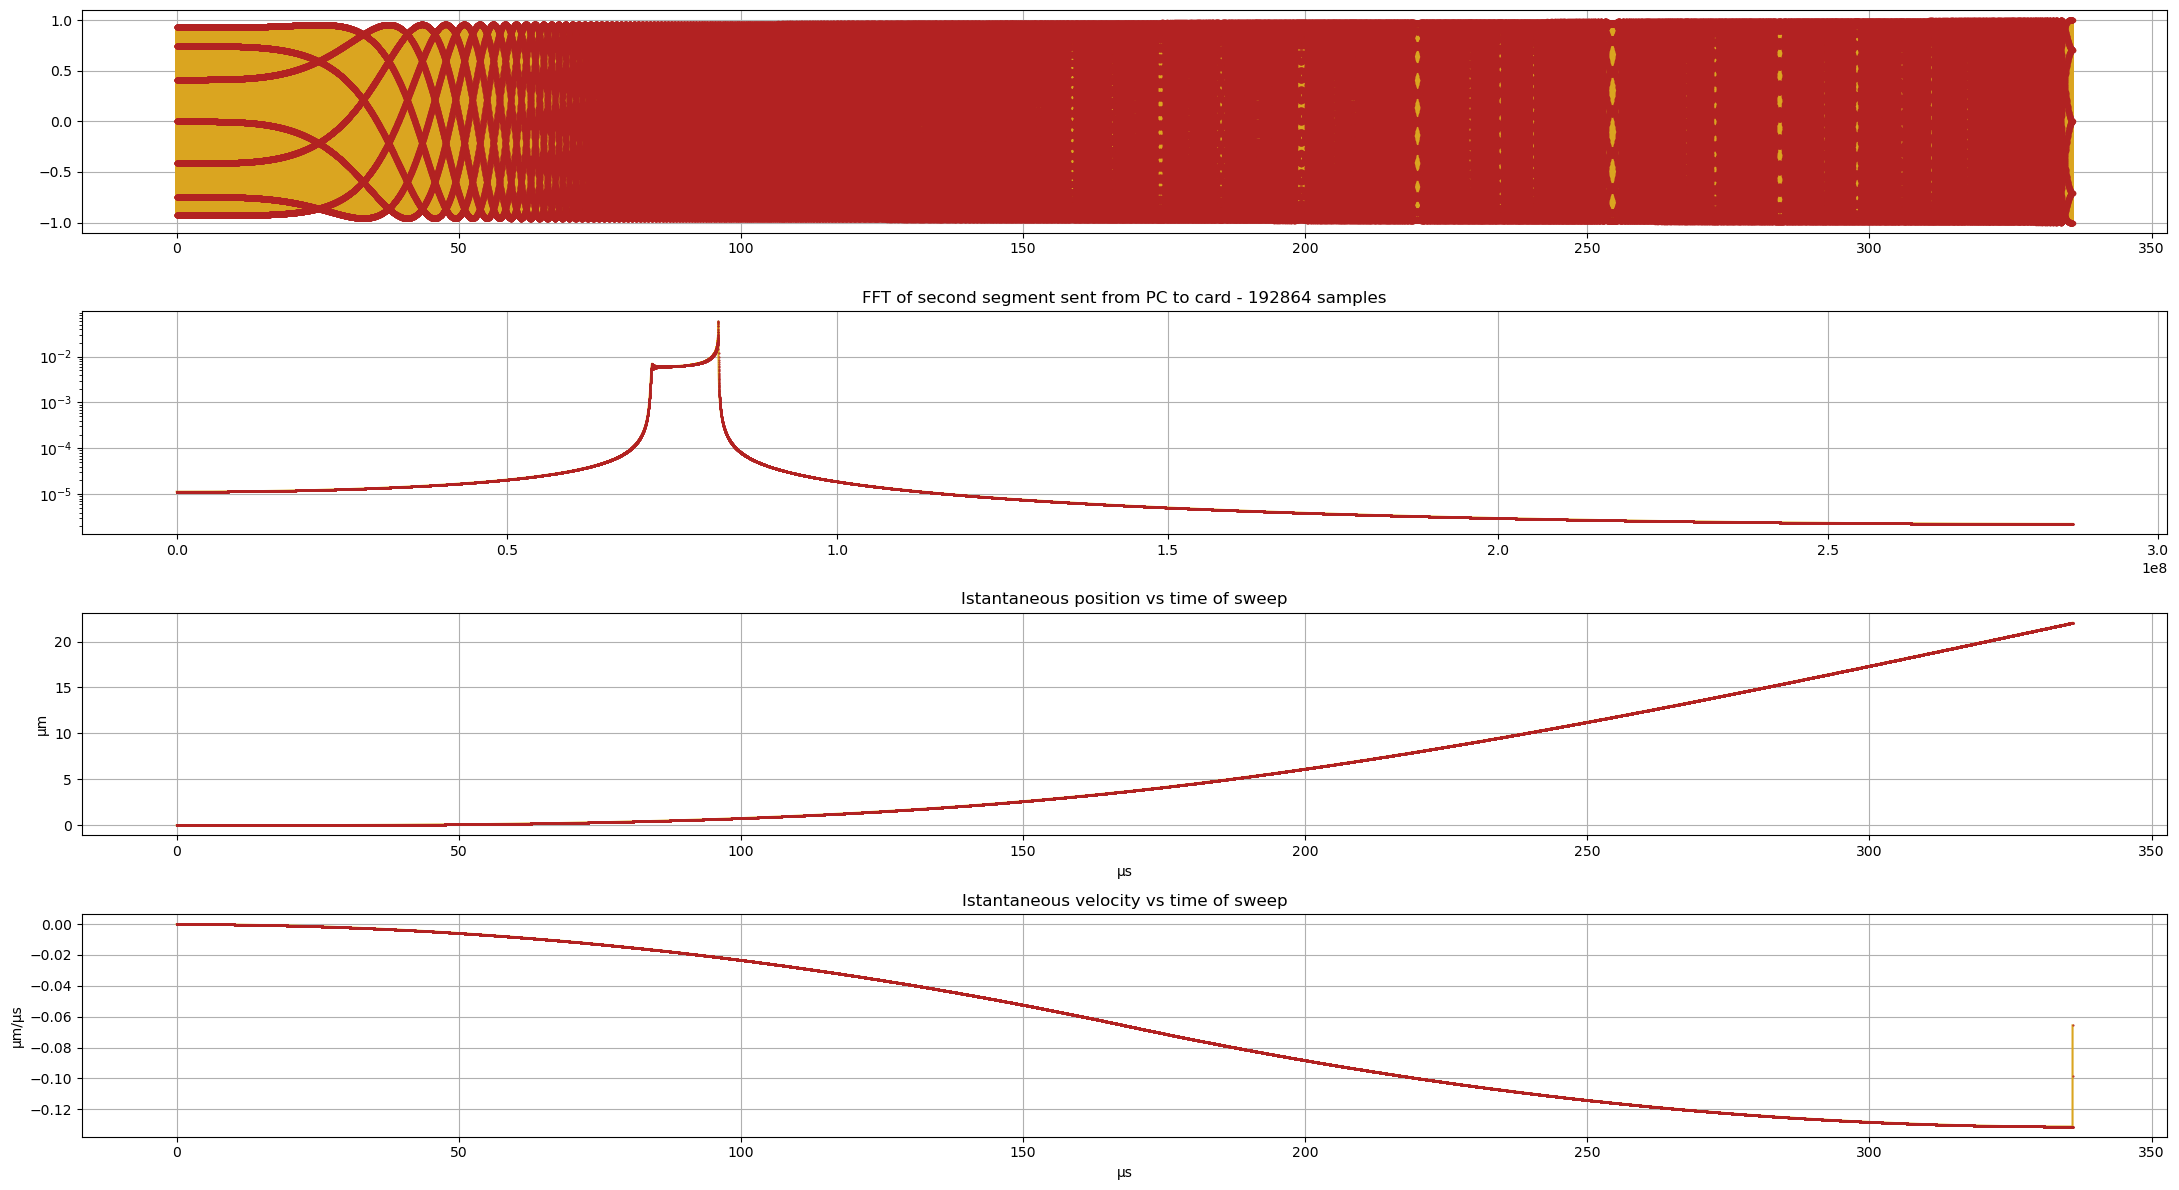

In [74]:
# Function to plot istantaneous frequency of signal sent - proxy of position (?)
def inst_freq(phase, sample_rate):
    # Remove 2*pi jumps
    phase_unwrapped = np.unwrap(phase)
    
    dt = 1.0 / sample_rate
    f_inst = np.gradient(phase_unwrapped, dt) / (2*np.pi)
    
    return f_inst*(2.15e-12) # conversion factor from Hz to meters

# Function to plot proxy of velocity
def inst_vel(phase, sample_rate):
    
    dt = 1.0 / sample_rate
    f_inst = inst_freq(phase, sample_rate)
    # derivative of f: df/dt
    dfdt = np.gradient(f_inst, dt)
    
    return dfdt

yf = np.abs(np.fft.rfft(sweep))/len(sweep)
xf = np.fft.rfftfreq(len(sweep), 1/sample_rate)

if sweep_mode == 'chirp':
    f_inst_sweep = inst_freq(wg._chirp_phase(wg.time_steps(samples_sw, sample_rate), f1, T_sweep, f2, 0.0), sample_rate)
    v_inst_sweep = inst_vel(wg._chirp_phase(wg.time_steps(samples_sw, sample_rate), f1, T_sweep, f2, 0.0), sample_rate)
elif sweep_mode == 'pq':
    f_inst_sweep = inst_freq(wg._pq_phase(wg.time_steps(samples_sw, sample_rate), f1, T_sweep, f2, 0.0), sample_rate)
    v_inst_sweep = inst_vel(wg._pq_phase(wg.time_steps(samples_sw, sample_rate), f1, T_sweep, f2, 0.0), sample_rate)
elif sweep_mode == 'pc':
    f_inst_sweep = inst_freq(wg._pc_phase(wg.time_steps(samples_sw, sample_rate), f1, T_sweep, f2, 0.0), sample_rate)
    v_inst_sweep = inst_vel(wg._pc_phase(wg.time_steps(samples_sw, sample_rate), f1, T_sweep, f2, 0.0), sample_rate)

# # Plot waves
fig, ax = plt.subplots(4, figsize=(22, 12))
ax[0].plot(wg.time_steps(samples_sw, sample_rate)*1e6, sweep, marker = '.', mec = "firebrick", mfc = "firebrick", color = "goldenrod")
ax[1].plot(xf, yf, marker = '.', mec = "firebrick", mfc = "firebrick", color = "goldenrod", ms=1)
ax[2].plot(wg.time_steps(samples_sw, sample_rate)*1e6, (f1*2.15e-12-f_inst_sweep)*1e6, marker = '.', mec = "firebrick", mfc = "firebrick", color = "goldenrod", ms=1)
ax[3].plot(wg.time_steps(samples_sw, sample_rate)*1e6, v_inst_sweep, marker = '.', mec = "firebrick", mfc = "firebrick", color = "goldenrod", ms=1)
ax[0].grid(); ax[1].grid(); ax[2].grid(); ax[3].grid()

ax[1].set_title(f'FFT of second segment sent from PC to card - {len(sweep)} samples')
ax[1].set_yscale('log')

ax[2].set_title('Istantaneous position vs time of sweep'); ax[2].set_xlabel('μs'); ax[2].set_ylabel('μm')
ax[3].set_title('Istantaneous velocity vs time of sweep'); ax[3].set_xlabel('μs'); ax[3].set_ylabel('μm/μs')
fig.tight_layout()
print(np.min(v_inst_sweep))
# fig, ax = plt.subplots(5, figsize=(22, 12))
# ax[0].plot(mono_one, marker = '.', mec = "firebrick", mfc = "firebrick", color = "goldenrod")
# ax[1].plot(xf, yf, marker = '.', mec = "firebrick", mfc = "firebrick", color = "goldenrod", ms=1)
# ax[1].set_xlim(min(f1,f2)-10e6, max(f1, f2)+10e6)
# ax[2].plot(mono_two, marker = '.', mec = "firebrick", mfc = "firebrick", color = "goldenrod")
# ax[3].plot(wg.time_steps(samples_sw, sample_rate)*1e6, (f1*2.15e-12-f_inst_sweep)*1e6, marker = '.', mec = "firebrick", mfc = "firebrick", color = "goldenrod", ms=1)
# ax[4].plot(wg.time_steps(samples_sw, sample_rate)*1e6, v_inst_sweep, marker = '.', mec = "firebrick", mfc = "firebrick", color = "goldenrod", ms=1)
# ax[0].grid(); ax[1].grid(); ax[2].grid(); ax[3].grid(); ax[4].grid()
# ax[0].set_title(f'first segment sent from PC to card - {len(mono_one)} samples')
# ax[1].set_title(f'FFT of second segment sent from PC to card - {len(sweep)} samples')
# ax[2].set_title(f'third segment sent from PC to card - {len(mono_two)} samples')
# ax[3].set_title('Istantaneous position vs time of sweep'); ax[3].set_xlabel('μs'); ax[3].set_ylabel('μm')
# ax[4].set_title('Istantaneous velocity vs time of sweep'); ax[4].set_xlabel('μs'); ax[4].set_ylabel('μm/μs')
# fig.tight_layout()

In [75]:
# Set up data to store in each memory segment and send to card
SC._set_up_segment(0, samples_w1)
SC._transfer_numpy_array_to_card(True, mono_one, True)
SC._set_up_segment(1, samples_sw)
SC._transfer_numpy_array_to_card(True, sweep, True)
SC._set_up_segment(2, samples_w2)
SC._transfer_numpy_array_to_card(True, mono_two, True)

In [76]:
# Set up sequence memory for each segment
current_step, current_segment = 0, 0
loop = 1# at each each step, the device will check if a trigger has been received (if >1, the trigger check will be done every n repeats)
next_step = 1
SC._set_up_sequence_memory(current_step, current_segment, loop, next_step, True)
current_step +=1
current_segment +=1
loop = 1
next_step +=1
SC._set_up_sequence_memory(current_step, current_segment, loop, next_step, False)
current_step +=1
current_segment +=1
next_step = 0 
SC._set_up_sequence_memory(current_step, current_segment, loop, next_step, True)

# Enable trigger - WATCH OUT FOR TYPE OF TRIGGER TERMINATION IMPEDANCE 50 or 1 MOhm
SC._enable_trigger() #! consider setting up trigger configuration from here rather than directly in the wrapper

# Read trigger configuration
term = SC.get_param('SPC_TRIG_TERM', 'int32'); mode = SC.get_param('SPC_TRIG_EXT0_MODE', 'int32')
ormask = SC.get_param('SPC_TRIG_ORMASK', 'int32')
lvl0 = SC.get_param('SPC_TRIG_EXT0_LEVEL0', 'int32'); lvl1 = SC.get_param('SPC_TRIG_EXT0_LEVEL1', 'int32')

print("Trigger configs")
print(f"SPC_TRIG_TERM (0=1MΩ,1=50Ω): {term}")
print(f"SPC_TRIG_EXT0_MODE (e.g. SPC_TM_POS): {mode}")
print(f"SPC_TRIG_ORMASK (bitmask): 0x{ormask:08x}")
print(f"SPC_TRIG_EXT0_LEVEL0 (mV): {lvl0}, LEVEL1 (mV): {lvl1}")
if lvl0 == 0:
    raise ValueError('Low level of Spectrum trigger is 0. Are you sure this is intended behaviour?')

Trigger configs
SPC_TRIG_TERM (0=1MΩ,1=50Ω): 0
SPC_TRIG_EXT0_MODE (e.g. SPC_TM_POS): 1
SPC_TRIG_ORMASK (bitmask): 0x00000002
SPC_TRIG_EXT0_LEVEL0 (mV): 2500, LEVEL1 (mV): 2500


In [77]:
# Start card
# set number of loops
# SC._loops(int(0))
SC._start_and_enable_trigger()
# SC._start_and_enable_gate()
# SC._start_and_wait_timeout(0)